# Librairies 📚

In [1]:
# =========================
# Standard library
# =========================
import os
import sys
from pathlib import Path
import time
import math
import re
import importlib

# =========================
# Data / scientific stack
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualisation
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# =========================
# Stats
# =========================
import scipy.stats as stats
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
import pingouin as pg
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import (
    LabelEncoder,
    MultiLabelBinarizer,
    OneHotEncoder,
    RobustScaler,
    StandardScaler,
)

# =========================
# Local imports (src/)
# =========================
# =========================
# Local imports (src/)
# =========================
PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

sys.path.append(os.path.abspath(".."))  # si notebook dans /notebooks


import src.utils.outliers as of
from src.utils.visualization import (
    plot_attrition_by_num, 
    plot_attrition_by_cat, 
    plot_odds_ratios, 
    plot_attrition_heatmaps,
    plot_top_spearman_corr,
    plot_strong_feature_correlations
)
import src.utils.analyse_bivariee as ab

/home/maxime/projects


# Import de la table 🪑

In [2]:
df_back_up = pd.read_csv("/home/maxime/projects/technova-attrition/data/interim/data_eda.csv")
df_back_up.head(2)

,Unnamed: 0,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annee_experience_totale,...,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,8,...,1,0,0,1,1,2,Infra & Cloud,Occasionnel,0,5
1,1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,10,...,0,1,3,2,8,1,Infra & Cloud,Frequent,1,7


In [3]:
df = df_back_up.copy()
df.shape
df.drop("Unnamed: 0",axis=1,inplace=True)

# Etape 1 - Premier nettoyage des données 🧹

In [4]:
df.poste.value_counts()

poste
Cadre Commercial           326
Assistant de Direction     292
Consultant                 259
Tech Lead                  145
Manager                    131
Senior Manager             102
Représentant Commercial     83
Directeur Technique         80
Ressources Humaines         52
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   object 
 3   revenu_mensuel                             1470 non-null   int64  
 4   statut_marital                             1470 non-null   object 
 5   departement                                1470 non-null   object 
 6   poste                                      1470 non-null   object 
 7   nombre_experiences_precedentes             1470 non-null   int64  
 8   annee_experience_totale                    1470 non-null   int64  
 9   annees_dans_l_entreprise                   1470 non-null   int64  
 10  annees_dans_le_poste_act

In [6]:
df.drop("id_employee",axis=1).describe().T

,count,mean,std,min,25%,50%,75%,max
age,1470.0,36.923810,9.135373,18.00,30.00,36.00,43.00,60.00
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.00,2911.00,4919.00,8379.00,19999.00
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.00,1.00,2.00,4.00,9.00
annee_experience_totale,1470.0,11.279592,7.780782,0.00,6.00,10.00,15.00,40.00
annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.00,3.00,5.00,9.00,40.00
annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.00,2.00,3.00,7.00,18.00
satisfaction_employee_environnement,1470.0,2.721769,1.093082,1.00,2.00,3.00,4.00,4.00
note_evaluation_precedente,1470.0,2.729932,0.711561,1.00,2.00,3.00,3.00,4.00
niveau_hierarchique_poste,1470.0,2.063946,1.106940,1.00,1.00,2.00,3.00,5.00
satisfaction_employee_nature_travail,1470.0,2.728571,1.102846,1.00,2.00,3.00,4.00,4.00


### Valeurs nulles 👌(❎ pas de valeur nulle)

In [7]:
df.isna().mean().sort_values(ascending=False)

id_employee                                  0.0
age                                          0.0
annees_depuis_la_derniere_promotion          0.0
frequence_deplacement                        0.0
domaine_etude                                0.0
niveau_education                             0.0
distance_domicile_travail                    0.0
code_sondage                                 0.0
nb_formations_suivies                        0.0
nombre_participation_pee                     0.0
a_quitte_l_entreprise                        0.0
satisfaction_global                          0.0
augementation_salaire_precedente             0.0
heure_supplementaires                        0.0
note_evaluation_actuelle                     0.0
eval_number                                  0.0
satisfaction_employee_equilibre_pro_perso    0.0
satisfaction_employee_equipe                 0.0
satisfaction_employee_nature_travail         0.0
niveau_hierarchique_poste                    0.0
note_evaluation_prec

### Suppression des doublons 👥 (❎ Pas de doublons)

In [8]:
df.duplicated().sum()

0

# Analyses bivariées 🪢

In [9]:
data = df.select_dtypes(include="number")
data = data.drop(columns=["id_employee","eval_number","code_sondage"])

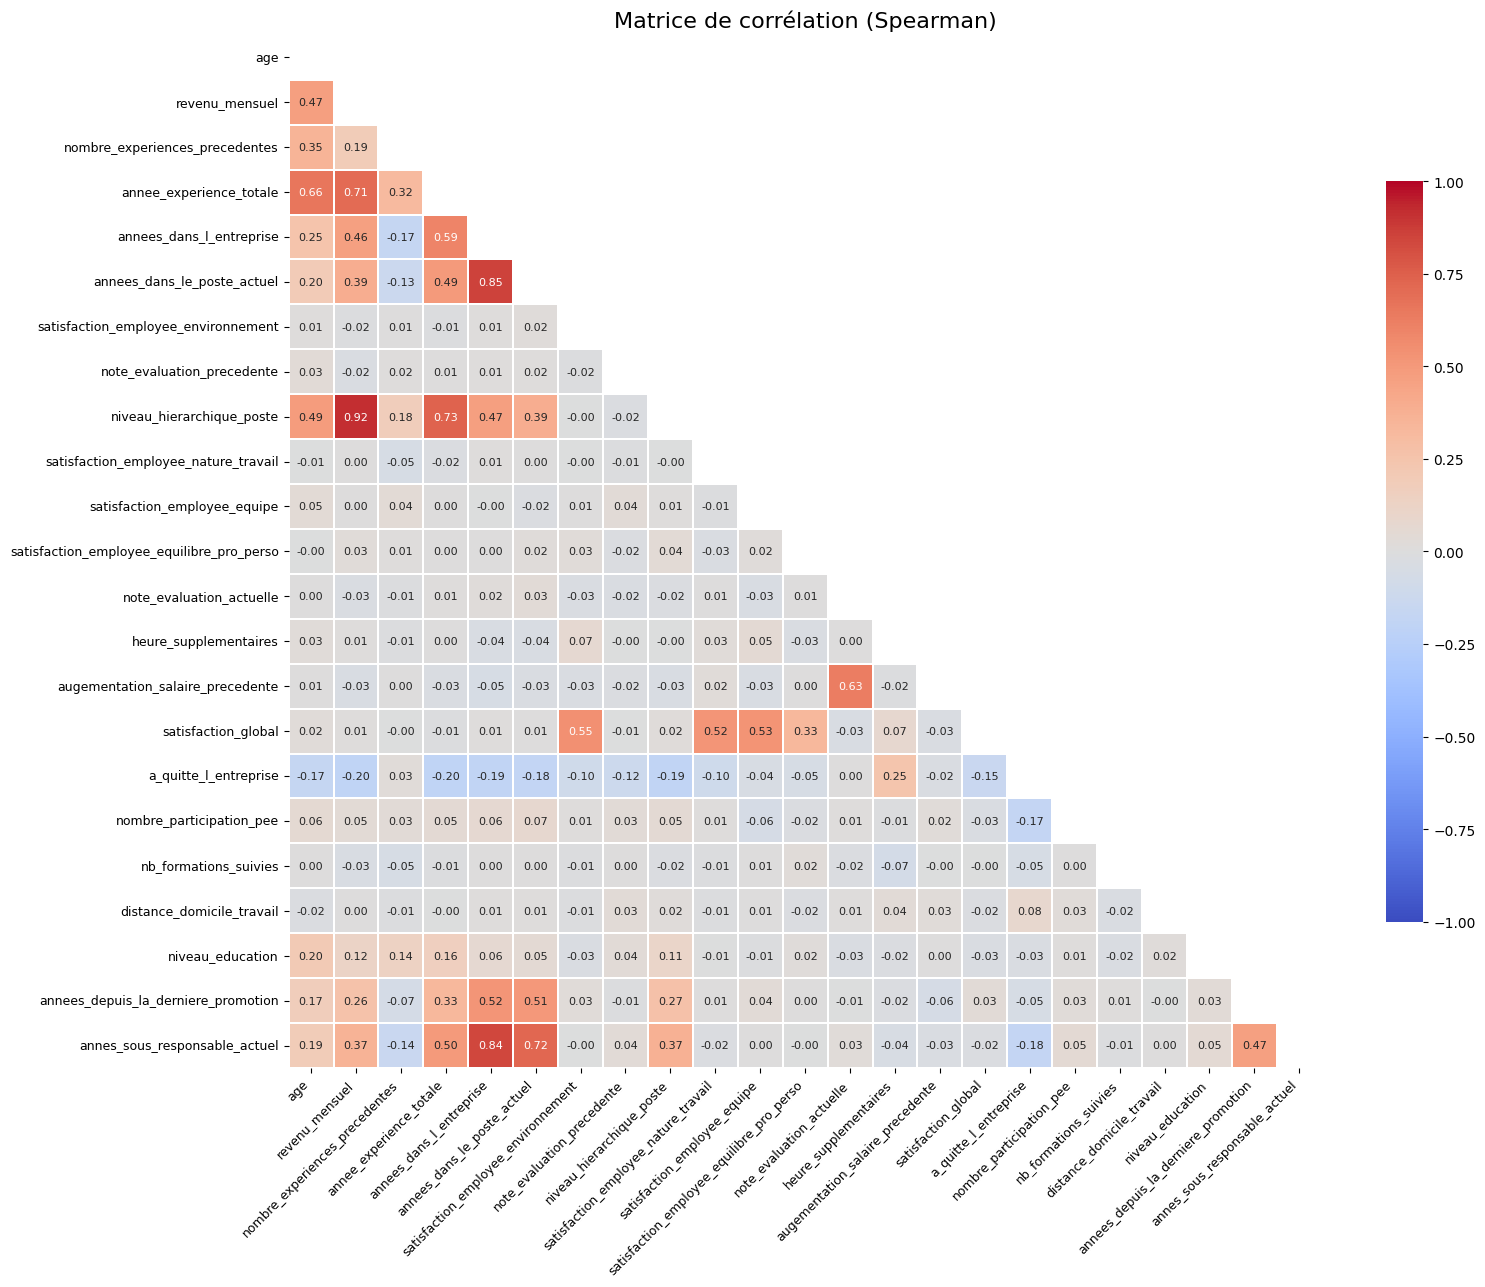

In [10]:
corr_matrix = data.corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 16))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},          # réduire taille des valeurs réduite
    linewidths=0.3,
    linecolor="white",
    square=True,                    # cellules carrées
    vmin=-1, vmax=1,                # échelle fixe (important pour comparaison)
    cbar_kws={"shrink": 0.5}
)

plt.title("Matrice de corrélation (Spearman)", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
corr = data.corr(method="spearman")

mask = np.triu(np.ones_like(corr, dtype=bool)) # matrice de 1 de la même taille que corr + garde uniquement la partie triangulaire supérieure
corr_tri = corr.mask(mask) # suppression de la diagonale et de la partie supérieur de la matrice

strong_corr = (pd.DataFrame(
    corr_tri.unstack()
    .dropna()
    .loc[lambda x: abs(x) > 0.7]
    .sort_values(ascending=False)
    .reset_index()
    )
)
strong_corr.columns = ["level_0", "level_1", "corr"]
strong_corr

,level_0,level_1,corr
0,revenu_mensuel,niveau_hierarchique_poste,0.920429
1,annees_dans_l_entreprise,annees_dans_le_poste_actuel,0.854000
2,annees_dans_l_entreprise,annes_sous_responsable_actuel,0.842803
3,annee_experience_totale,niveau_hierarchique_poste,0.734678
4,annees_dans_le_poste_actuel,annes_sous_responsable_actuel,0.724754
5,revenu_mensuel,annee_experience_totale,0.710024


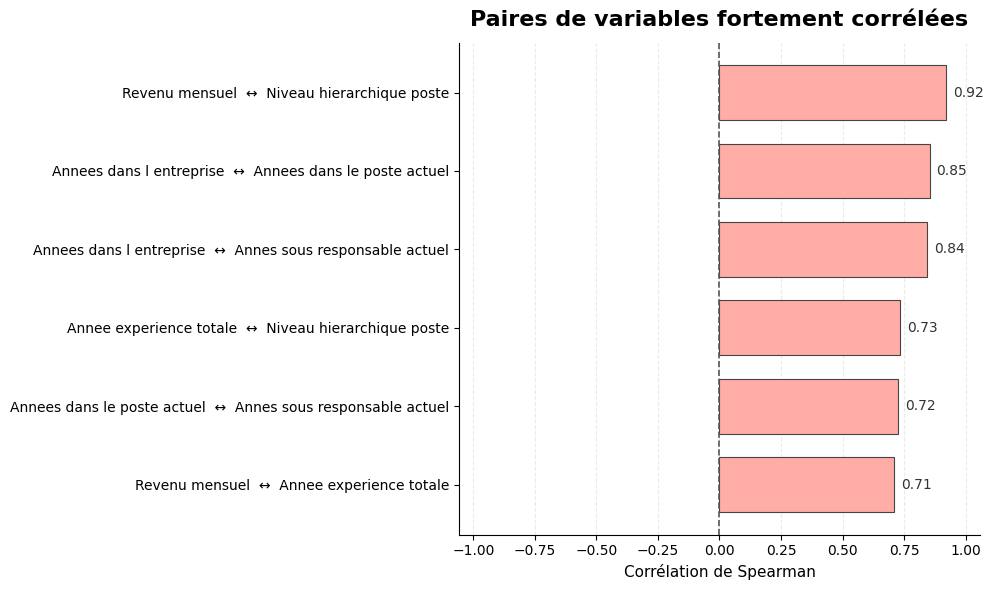

In [12]:
plot_strong_feature_correlations(strong_corr)

In [13]:
strong_corr_features = list(set(list(strong_corr['level_0'].values) + list(strong_corr['level_1'].values)))
X = df[strong_corr_features].replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(len(X.columns))]
vif_data[vif_data['VIF'] > 5]

,feature,VIF
0,annes_sous_responsable_actuel,6.316925
1,annees_dans_l_entreprise,8.980049
2,annees_dans_le_poste_actuel,6.085786
3,revenu_mensuel,23.931339
4,niveau_hierarchique_poste,29.033025
5,annee_experience_totale,9.726838


In [14]:
data.satisfaction_global.value_counts()

satisfaction_global
2.75    272
3.00    265
2.50    239
2.25    196
3.25    185
3.50    106
2.00     98
1.75     38
3.75     35
1.50     23
4.00      6
1.25      6
1.00      1
Name: count, dtype: int64

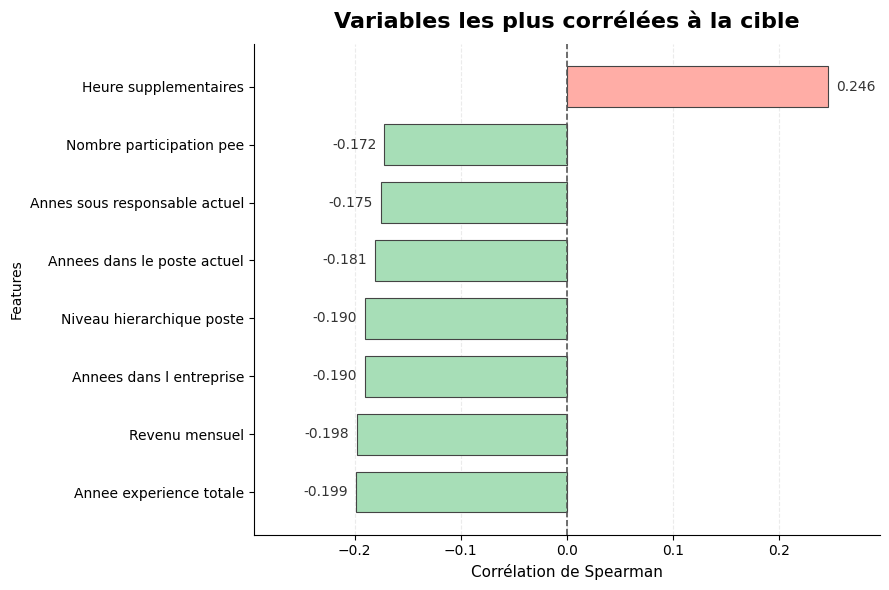

annee_experience_totale         -0.199002
revenu_mensuel                  -0.198305
annees_dans_l_entreprise        -0.190419
niveau_hierarchique_poste       -0.190370
annees_dans_le_poste_actuel     -0.180623
annes_sous_responsable_actuel   -0.175355
nombre_participation_pee        -0.172296
heure_supplementaires            0.246118
Name: a_quitte_l_entreprise, dtype: float64

In [15]:
plot_top_spearman_corr(
    data,
    target="a_quitte_l_entreprise",
    top_n=8
)

## Colonnes numériques

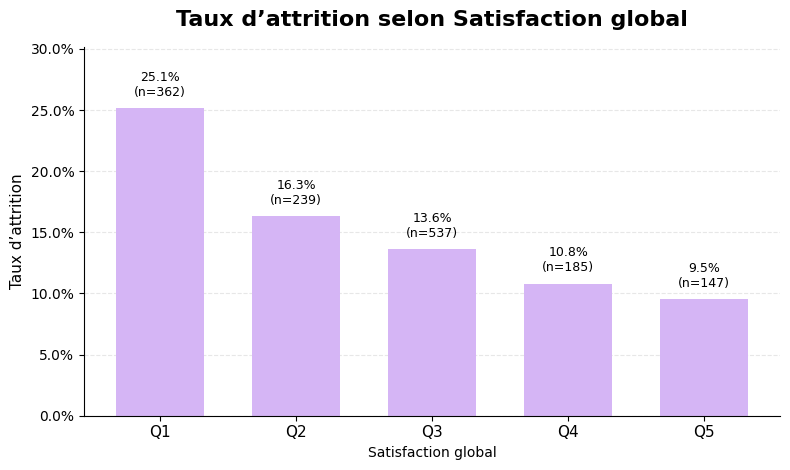

,satisfaction_global,attrition_rate,n,bin_label,left,right
0,"(0.999, 2.25]",0.251381,362,Q1,0.999,2.25
1,"(2.25, 2.5]",0.163180,239,Q2,2.250,2.50
2,"(2.5, 3.0]",0.135940,537,Q3,2.500,3.00
3,"(3.0, 3.25]",0.108108,185,Q4,3.000,3.25
4,"(3.25, 4.0]",0.095238,147,Q5,3.250,4.00


In [16]:
plot_attrition_by_num(data, "satisfaction_global", show_range = False)

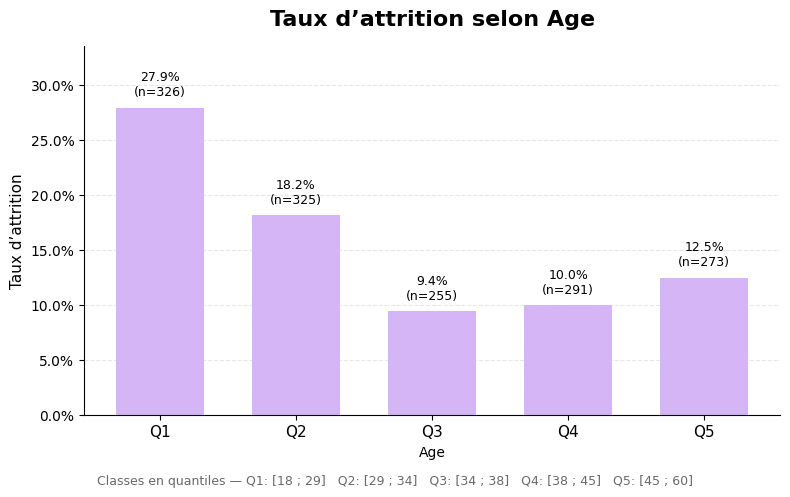

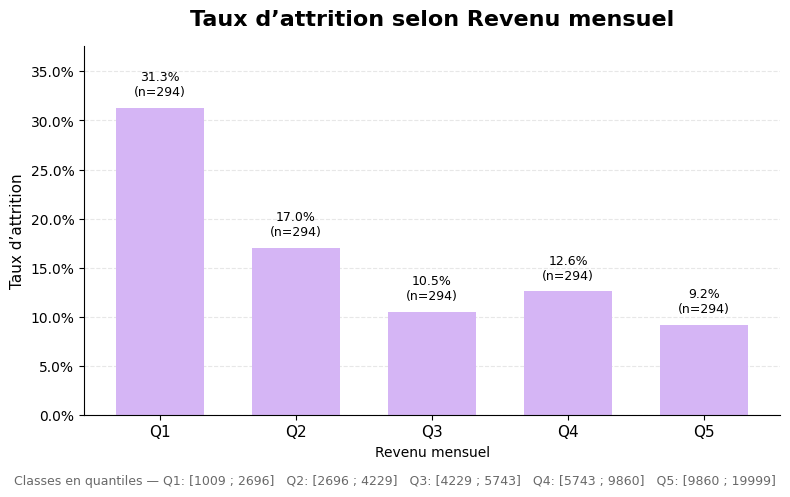

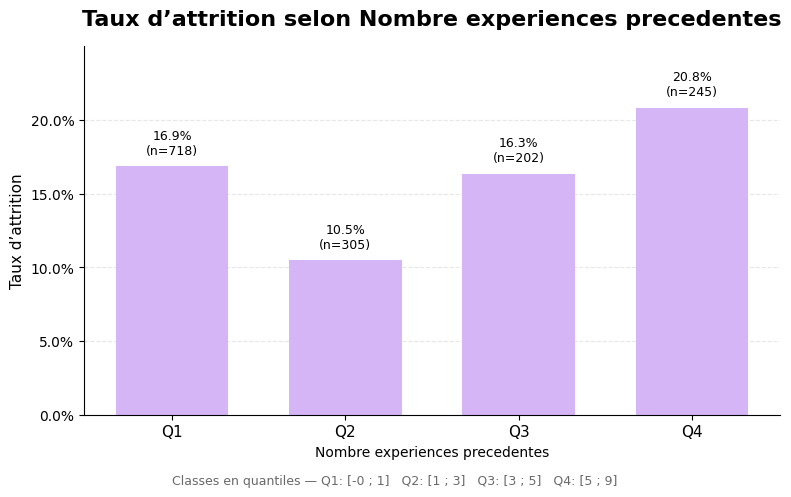

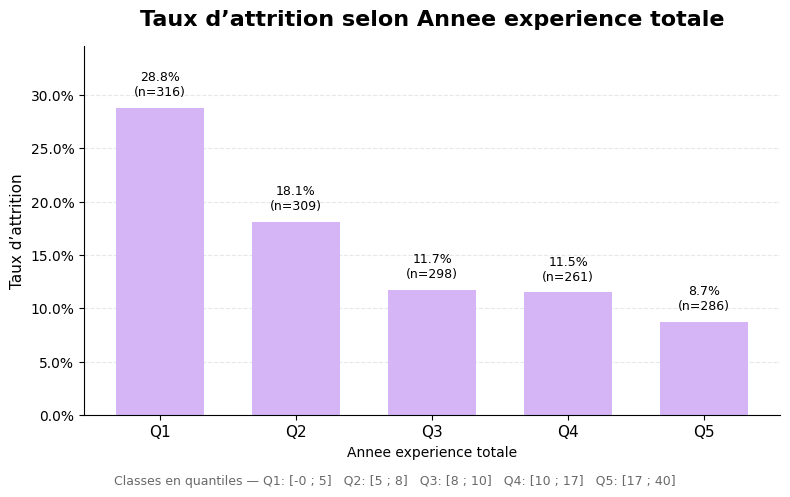

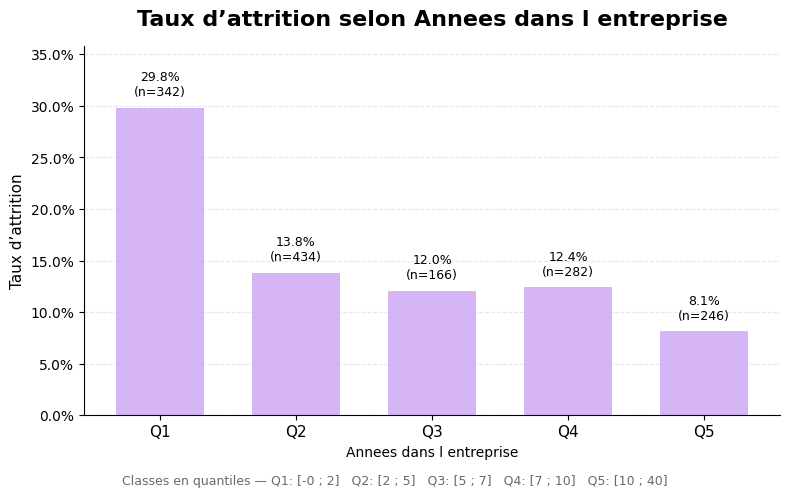

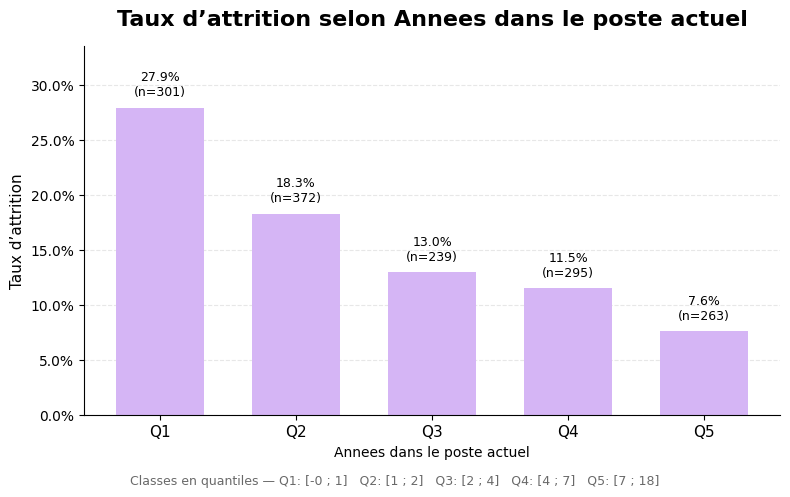

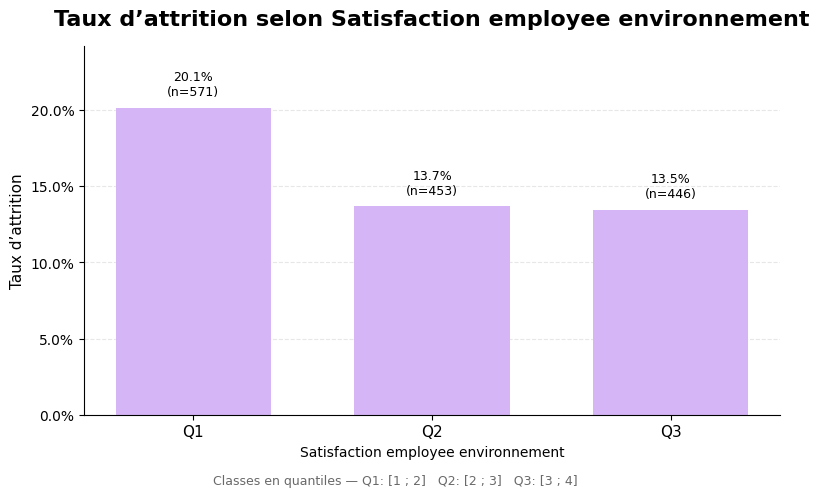

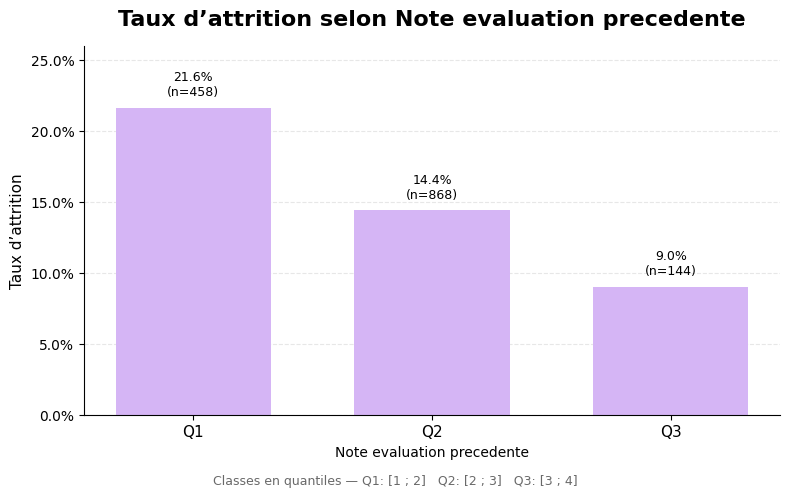

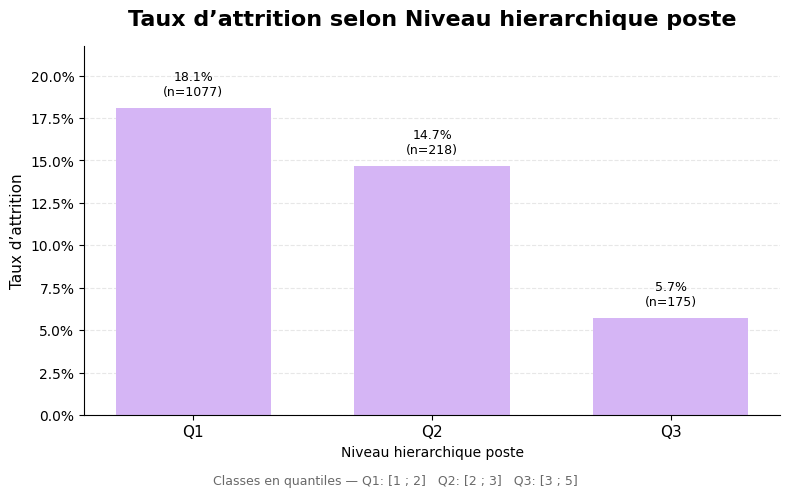

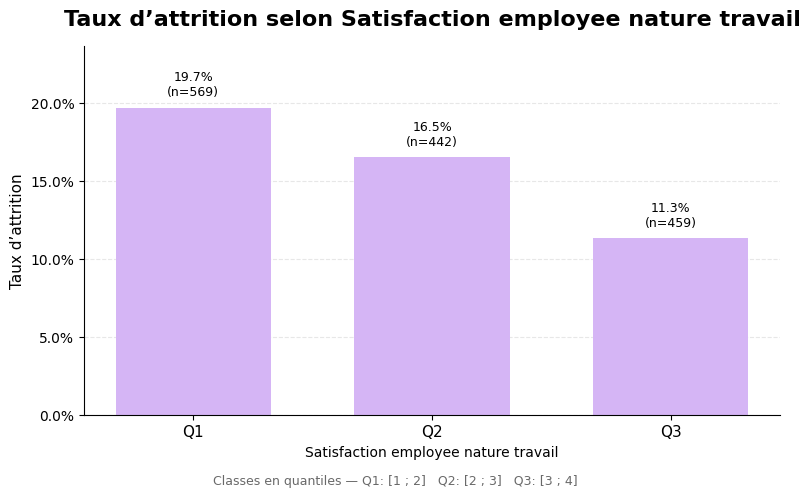

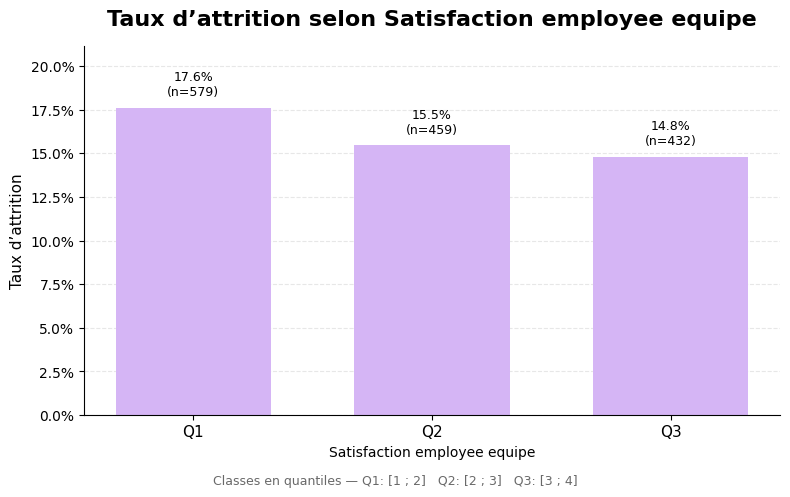

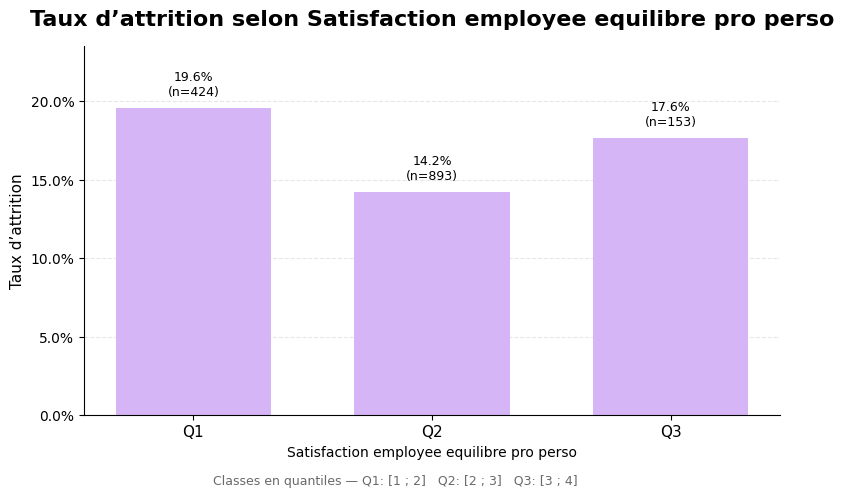

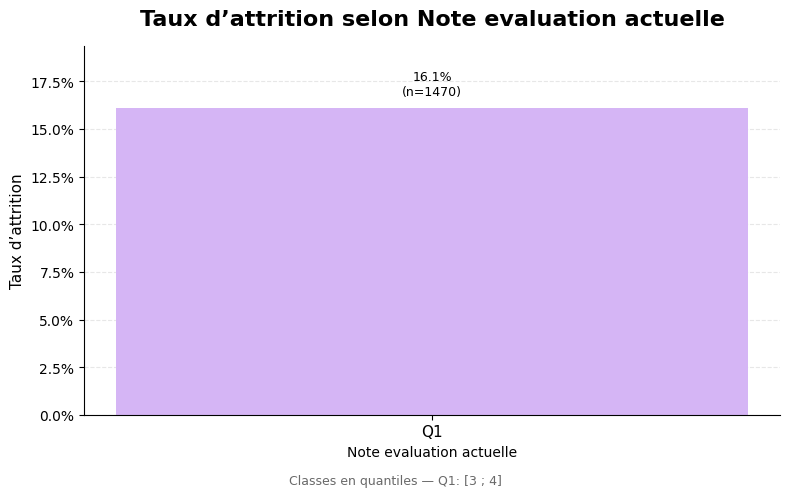

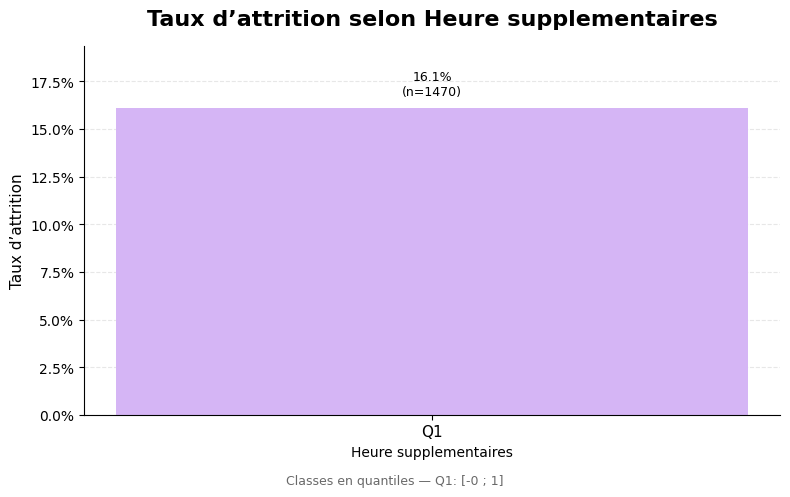

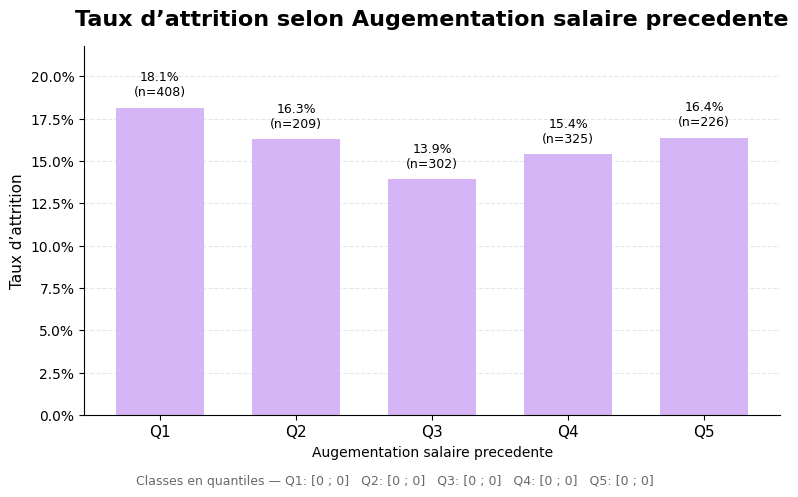

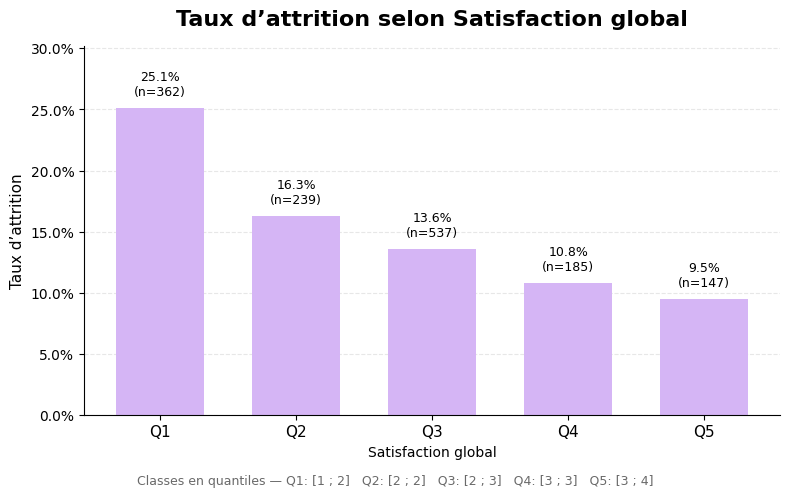

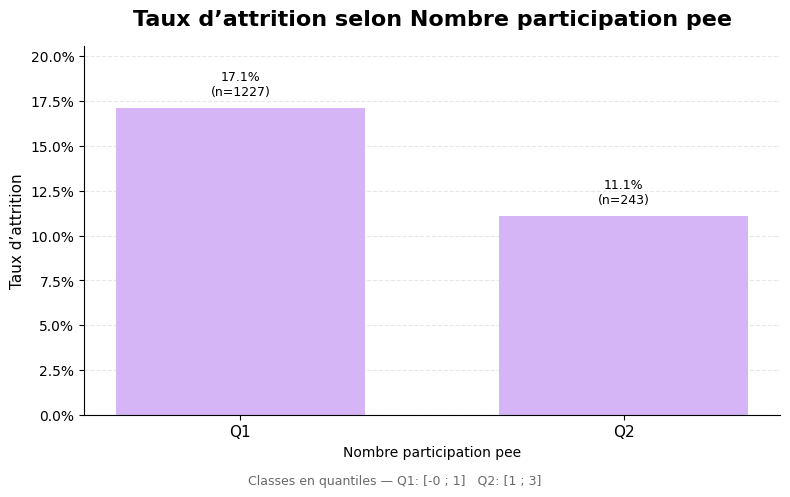

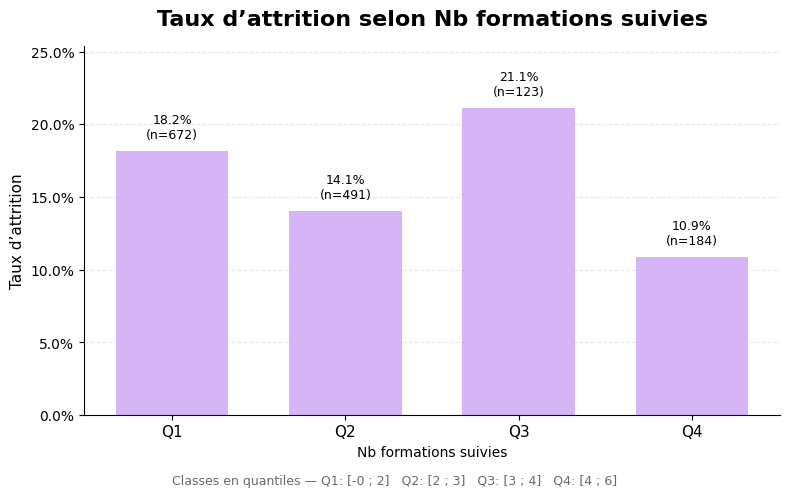

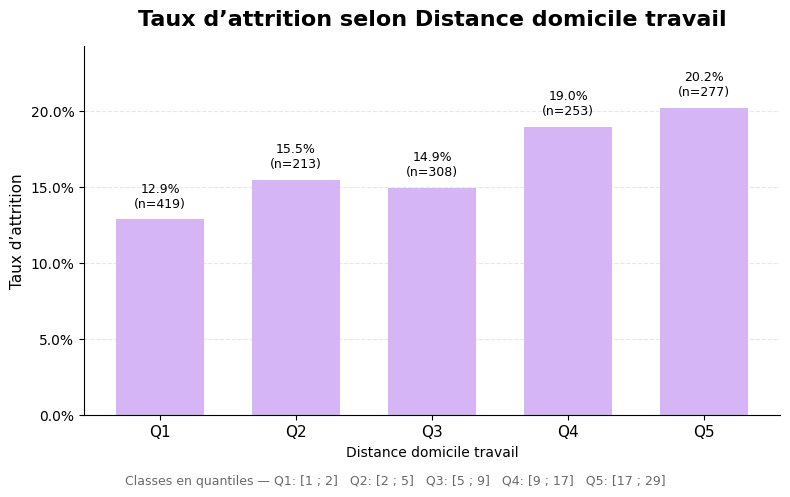

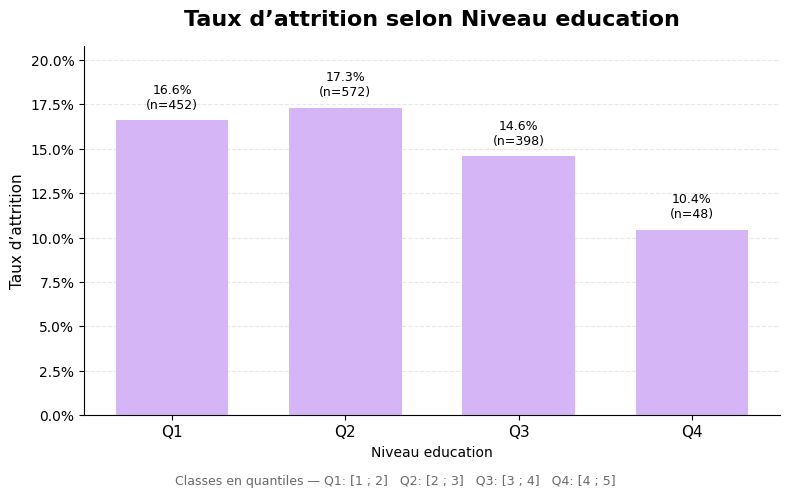

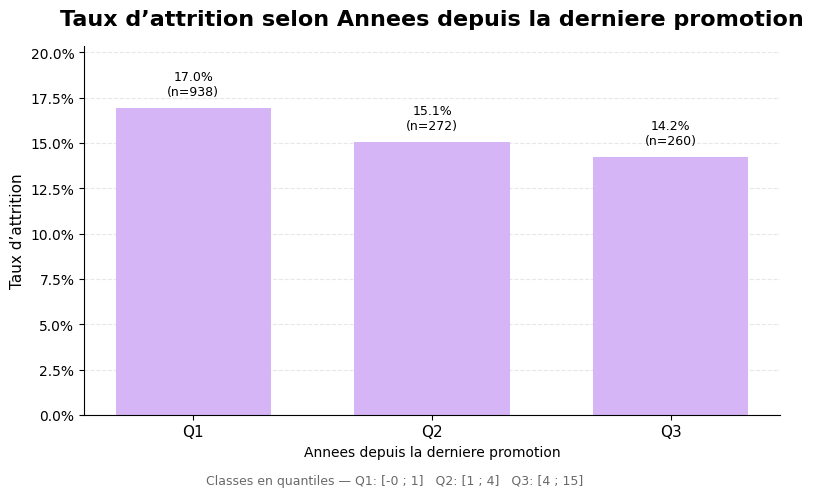

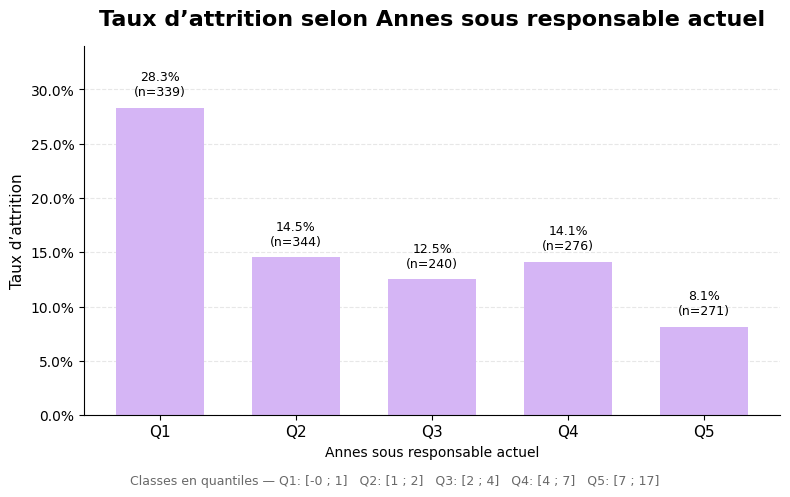

In [ ]:
data = df.drop(columns=["id_employee", "eval_number", "code_sondage"])

for col in data.select_dtypes(include="number").columns:
    if col != "a_quitte_l_entreprise":
        plot_attrition_by_num(data, col)

## Colonnes catégorielles

In [ ]:
df.select_dtypes(exclude="number").columns

Index(['genre', 'statut_marital', 'departement', 'poste', 'domaine_etude',
       'frequence_deplacement'],
      dtype='object')

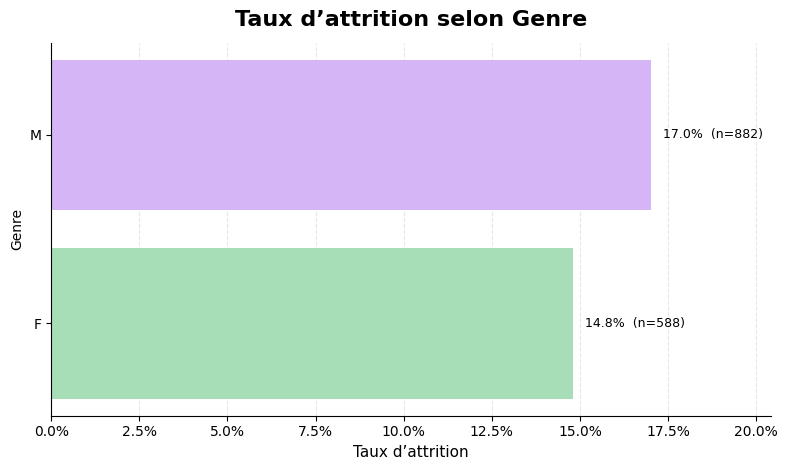

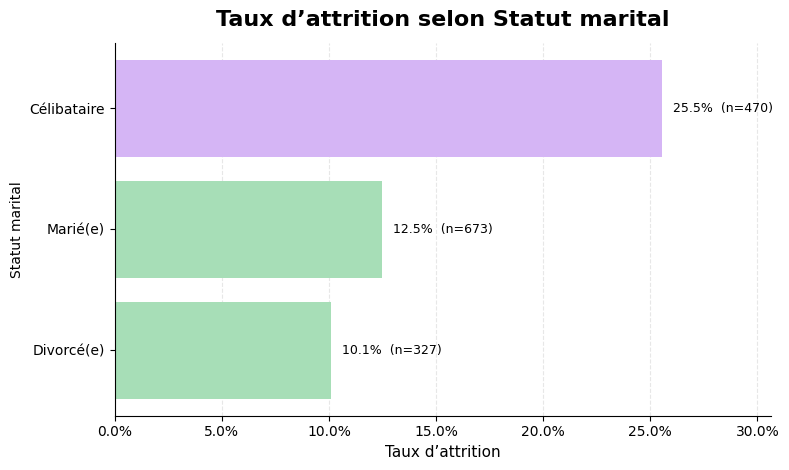

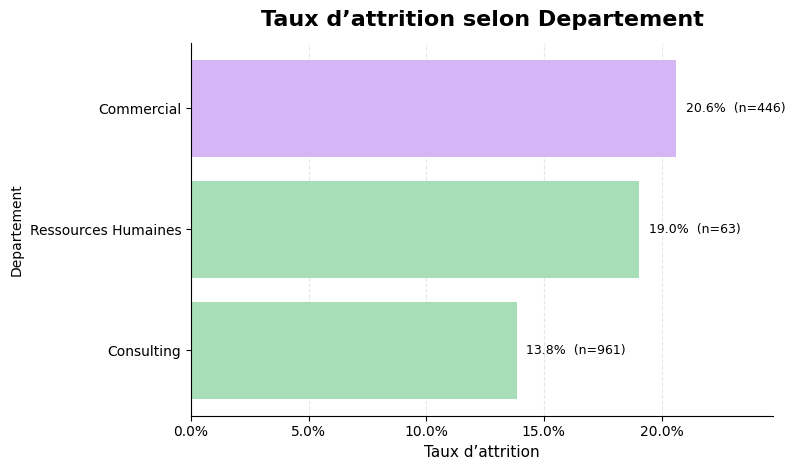

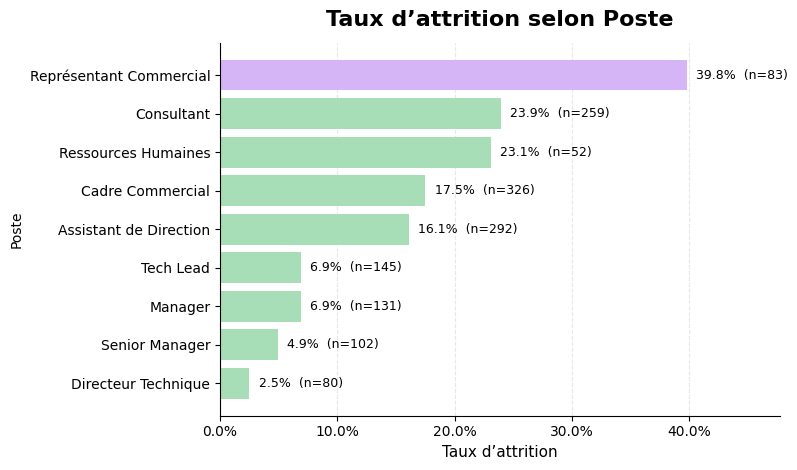

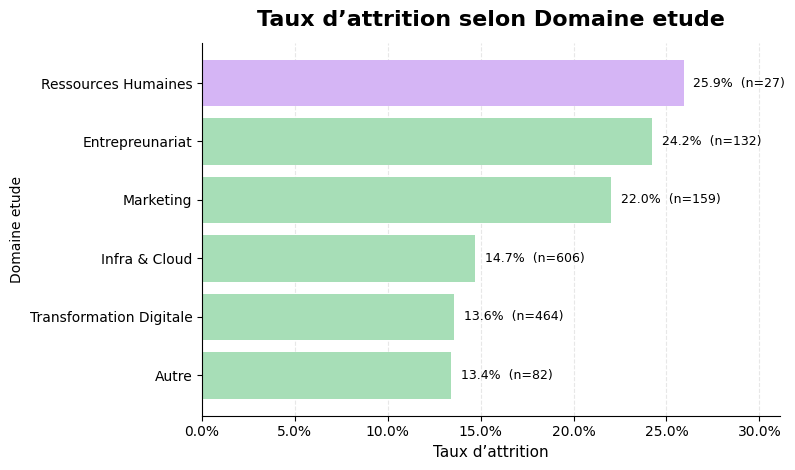

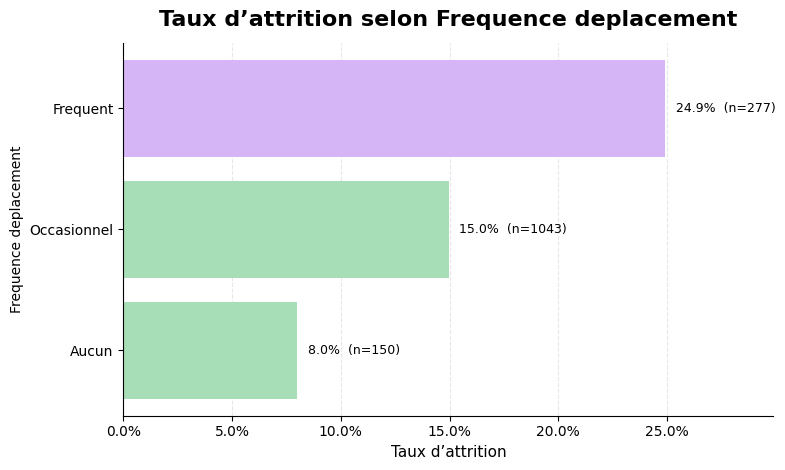

In [ ]:
cat_cols = [
    "genre",
    "statut_marital",
    "departement",
    "poste",
    "domaine_etude",
    "frequence_deplacement",
]

for col in cat_cols:
    plot_attrition_by_cat(df, col, min_count=10)

In [ ]:
# def plot_attrition_heatmap(df, col,norme='all'):
#     ct = pd.crosstab( df[col], df["a_quitte_l_entreprise"], normalize=norme)

#     sns.heatmap(
#         ct,
#         annot=True,
#         fmt=".2%",
#         cmap="Blues",
#         linewidths=0.5
#     )
#     plt.title(f"Attrition par {col}")
#     plt.show()

# for col in ['genre', 'statut_marital', 'departement', 'poste', 'domaine_etude', 'frequence_deplacement', 'revenu_bin']:
#     plot_attrition_heatmap(df, col, norme="columns")

# Analyse multivariée

Objectif : compléter l’analyse bivariée en observant des **combinaisons de facteurs RH**.

L’idée n’est pas de conclure à des causalités, mais de vérifier si certains signaux restent cohérents lorsqu’ils sont observés ensemble : satisfaction, revenu, poste, déplacements, heures supplémentaires, ancienneté et statut marital.


## 1. Création de segments pour comparer des profils combinés

On discrétise quelques variables continues afin d’obtenir des segments lisibles côté métier. Ces regroupements servent uniquement à l’EDA, pas au modèle final.


In [ ]:
from IPython.display import display

TARGET = "a_quitte_l_entreprise"

df_multivar = df.copy()

df_multivar["satisfaction_bin_eda"] = pd.qcut(
    df_multivar["satisfaction_global"],
    q=3,
    labels=["satisfaction_basse", "satisfaction_moyenne", "satisfaction_haute"],
    duplicates="drop",
)

df_multivar["revenu_bin_eda"] = pd.qcut(
    df_multivar["revenu_mensuel"],
    q=3,
    labels=["revenu_bas", "revenu_moyen", "revenu_haut"],
    duplicates="drop",
)

df_multivar["age_bin_eda"] = pd.cut(
    df_multivar["age"],
    bins=[17, 30, 40, 50, 65],
    labels=["<=30", "31-40", "41-50", ">50"],
    include_lowest=True,
)

df_multivar["anciennete_bin_eda"] = pd.cut(
    df_multivar["annees_dans_l_entreprise"],
    bins=[-1, 2, 5, 10, 50],
    labels=["0-2 ans", "3-5 ans", "6-10 ans", ">10 ans"],
)


def attrition_rate_by_segments(data, group_cols, min_n=30):
    summary = (
        data.groupby(group_cols, observed=True)[TARGET]
        .agg(n="size", nb_departs="sum", taux_attrition="mean")
        .reset_index()
    )
    summary = summary[summary["n"] >= min_n].copy()
    summary["taux_attrition"] = (summary["taux_attrition"] * 100).round(1)

    return summary.sort_values("taux_attrition", ascending=False)


## 2. Profils combinés avec les taux d’attrition les plus élevés

On filtre les segments trop petits afin d’éviter de surinterpréter des combinaisons rares.


In [ ]:
segment_analyses = {
    "Poste x fréquence de déplacement": attrition_rate_by_segments(
        df_multivar,
        ["poste", "frequence_deplacement"],
        min_n=20,
    ),
    "Revenu x satisfaction": attrition_rate_by_segments(
        df_multivar,
        ["revenu_bin_eda", "satisfaction_bin_eda"],
        min_n=30,
    ),
    "Statut marital x heures supplémentaires": attrition_rate_by_segments(
        df_multivar,
        ["statut_marital", "heure_supplementaires"],
        min_n=30,
    ),
    "Âge x ancienneté": attrition_rate_by_segments(
        df_multivar,
        ["age_bin_eda", "anciennete_bin_eda"],
        min_n=30,
    ),
}

for title, table in segment_analyses.items():
    print(f"\n{title}")
    display(table.head(12))



Poste x fréquence de déplacement


,poste,frequence_deplacement,n,nb_departs,taux_attrition
16,Représentant Commercial,Frequent,23,15,65.2
17,Représentant Commercial,Occasionnel,55,18,32.7
7,Consultant,Frequent,51,16,31.4
1,Assistant de Direction,Frequent,54,15,27.8
8,Consultant,Occasionnel,180,44,24.4
4,Cadre Commercial,Frequent,59,13,22.0
20,Ressources Humaines,Occasionnel,38,8,21.1
5,Cadre Commercial,Occasionnel,228,40,17.5
0,Assistant de Direction,Aucun,28,4,14.3
2,Assistant de Direction,Occasionnel,210,28,13.3



Revenu x satisfaction


,revenu_bin_eda,satisfaction_bin_eda,n,nb_departs,taux_attrition
0,revenu_bas,satisfaction_basse,199,65,32.7
1,revenu_bas,satisfaction_moyenne,181,44,24.3
2,revenu_bas,satisfaction_haute,110,19,17.3
3,revenu_moyen,satisfaction_basse,202,35,17.3
6,revenu_haut,satisfaction_basse,200,30,15.0
7,revenu_haut,satisfaction_moyenne,178,15,8.4
4,revenu_moyen,satisfaction_moyenne,178,14,7.9
5,revenu_moyen,satisfaction_haute,110,8,7.3
8,revenu_haut,satisfaction_haute,112,7,6.2



Statut marital x heures supplémentaires


,statut_marital,heure_supplementaires,n,nb_departs,taux_attrition
1,Célibataire,1,131,65,49.6
5,Marié(e),1,186,43,23.1
3,Divorcé(e),1,99,19,19.2
0,Célibataire,0,339,55,16.2
4,Marié(e),0,487,41,8.4
2,Divorcé(e),0,228,14,6.1



Âge x ancienneté


,age_bin_eda,anciennete_bin_eda,n,nb_departs,taux_attrition
0,<=30,0-2 ans,130,59,45.4
4,31-40,0-2 ans,122,33,27.0
1,<=30,3-5 ans,133,22,16.5
2,<=30,6-10 ans,111,18,16.2
14,>50,6-10 ans,41,6,14.6
10,41-50,6-10 ans,90,13,14.4
5,31-40,3-5 ans,175,25,14.3
15,>50,>10 ans,35,5,14.3
9,41-50,3-5 ans,83,9,10.8
8,41-50,0-2 ans,66,7,10.6


## 3. Visualisation des interactions entre signaux RH

Ces heatmaps permettent de lire le taux d’attrition moyen pour des combinaisons de facteurs, plutôt que variable par variable.


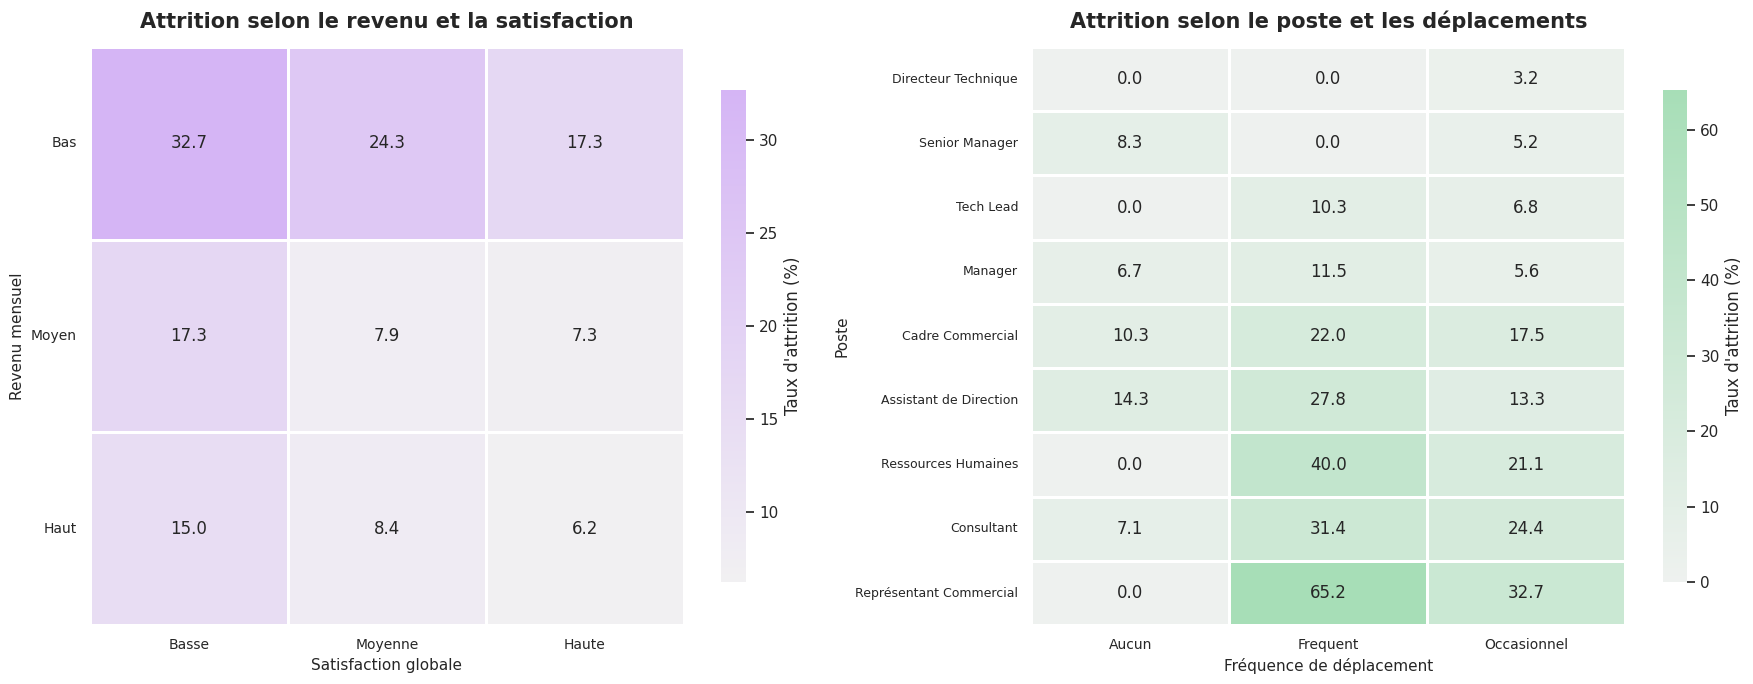

In [ ]:
plot_attrition_heatmaps(df_multivar, target=TARGET)

## 4. Régression logistique exploratoire

Cette régression n’est pas le modèle final. Elle sert à vérifier quels signaux restent associés à l’attrition lorsque plusieurs variables sont prises en compte simultanément.

Les odds ratios s’interprètent ainsi :

- `odds_ratio > 1` : facteur associé à une probabilité de départ plus élevée ;
- `odds_ratio < 1` : facteur associé à une probabilité de départ plus faible ;
- `p_value` : indicateur statistique exploratoire, à ne pas interpréter comme preuve causale.


In [ ]:
import statsmodels.formula.api as smf

model_data = df_multivar[
    [
        TARGET,
        "satisfaction_global",
        "revenu_mensuel",
        "age",
        "distance_domicile_travail",
        "heure_supplementaires",
        "niveau_hierarchique_poste",
        "annees_dans_le_poste_actuel",
        "note_evaluation_precedente",
        "statut_marital",
        "departement",
        "frequence_deplacement",
    ]
].dropna().copy()

model_data["revenu_mensuel_k"] = model_data["revenu_mensuel"] / 1000

formula = (
    f"{TARGET} ~ satisfaction_global + revenu_mensuel_k + age + "
    "distance_domicile_travail + heure_supplementaires + "
    "niveau_hierarchique_poste + annees_dans_le_poste_actuel + "
    "note_evaluation_precedente + C(statut_marital) + C(departement) + "
    "C(frequence_deplacement)"
)

logit_model = smf.logit(formula=formula, data=model_data).fit(
    disp=False,
    maxiter=200,
)

odds_ratios = pd.DataFrame(
    {
        "feature": logit_model.params.index,
        "odds_ratio": np.exp(logit_model.params),
        "p_value": logit_model.pvalues,
    }
)

odds_ratios = odds_ratios[odds_ratios["feature"] != "Intercept"].copy()
odds_ratios["odds_ratio"] = odds_ratios["odds_ratio"].round(3)
odds_ratios["p_value"] = odds_ratios["p_value"].round(4)
odds_ratios["significatif_5pct"] = odds_ratios["p_value"] < 0.05

odds_ratios.sort_values("odds_ratio", ascending=False)


,feature,odds_ratio,p_value,significatif_5pct
heure_supplementaires,heure_supplementaires,5.462,0.0000,True
C(frequence_deplacement)[T.Frequent],C(frequence_deplacement)[T.Frequent],5.225,0.0000,True
C(frequence_deplacement)[T.Occasionnel],C(frequence_deplacement)[T.Occasionnel],2.311,0.0188,True
distance_domicile_travail,distance_domicile_travail,1.038,0.0002,True
C(departement)[T.Ressources Humaines],C(departement)[T.Ressources Humaines],1.029,0.9423,False
revenu_mensuel_k,revenu_mensuel_k,1.001,0.9843,False
age,age,0.978,0.0342,True
annees_dans_le_poste_actuel,annees_dans_le_poste_actuel,0.900,0.0004,True
niveau_hierarchique_poste,niveau_hierarchique_poste,0.646,0.0930,False
note_evaluation_precedente,note_evaluation_precedente,0.585,0.0000,True


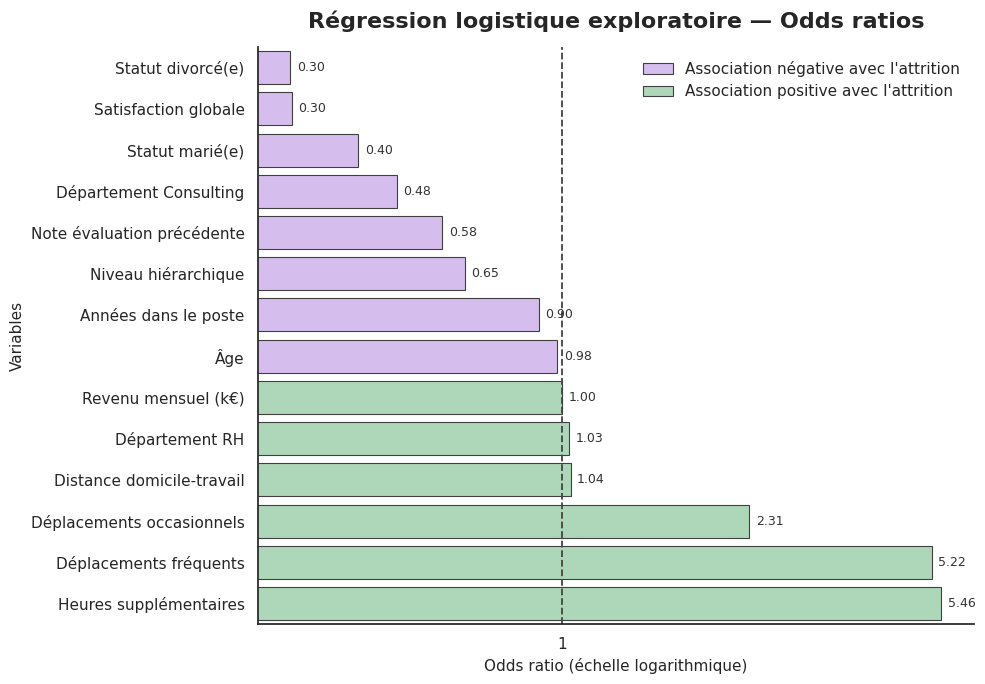

In [ ]:
feature_label_map = {
    "heure_supplementaires": "Heures supplémentaires",
    "C(frequence_deplacement)[T.Frequent]": "Déplacements fréquents",
    "C(frequence_deplacement)[T.Occasionnel]": "Déplacements occasionnels",
    "distance_domicile_travail": "Distance domicile-travail",
    "age": "Âge",
    "annees_dans_le_poste_actuel": "Années dans le poste",
    "niveau_hierarchique_poste": "Niveau hiérarchique",
    "note_evaluation_precedente": "Note évaluation précédente",
    "C(departement)[T.Consulting]": "Département Consulting",
    "C(departement)[T.Ressources Humaines]": "Département RH",
    "C(statut_marital)[T.Marié(e)]": "Statut marié(e)",
    "C(statut_marital)[T.Divorcé(e)]": "Statut divorcé(e)",
    "satisfaction_global": "Satisfaction globale",
    "revenu_mensuel_k": "Revenu mensuel (k€)",
}

or_plot = odds_ratios.copy()
or_plot["feature_label"] = or_plot["feature"].map(feature_label_map).fillna(or_plot["feature"])
or_plot["direction"] = np.where(
    or_plot["odds_ratio"] >= 1,
    "OR > 1 : Association positive avec l'attrition",
    "OR < 1 : Association négative avec l'attrition",
)

# plt.figure(figsize=(10, 7))
# sns.barplot(
#     data=or_plot.sort_values("odds_ratio", ascending=True),
#     x="odds_ratio",
#     y="feature_label",
#     hue="direction",
#     dodge=False,
# )
# plt.axvline(1, color="black", linestyle="--", linewidth=1)
# plt.xscale("log")
# plt.title("Régression logistique exploratoire - odds ratios")
# plt.xlabel("Odds ratio, échelle log")
# plt.ylabel("Features")
# plt.legend(title="")
# plt.tight_layout()
# plt.show()

plot_odds_ratios(or_plot)


### Synthèse multivariée

Les analyses multivariées confirment que l’attrition n’est pas portée par un facteur isolé. Les combinaisons les plus à risque cumulent souvent plusieurs signaux : poste exposé, déplacements fréquents, satisfaction plus faible, revenu relatif plus bas ou heures supplémentaires.

La régression logistique exploratoire montre aussi que certains signaux restent associés à l’attrition lorsqu’on contrôle plusieurs variables simultanément, notamment les heures supplémentaires, la fréquence de déplacement, la satisfaction globale, la note d’évaluation précédente, l’âge et l’ancienneté dans le poste.
